# 附：Codes {.nonumbered}

本 notebook 为 `tobit_model_lec_v7.ipynb` 生成模拟数据、估计结果和配图。

核心设定：

$$
B_i^*
=
\alpha+\beta_1 opportunity_i+\beta_2 collateral_i-\beta_3 cash_i+u_i
$$

$$
B_i=\max(0,B_i^*)
$$

其中 $B_i^*$ 是企业潜在净借款需求，$B_i$ 是实际观测到的银行贷款金额。

In [55]:
# ------------------------------------------------------------
# 0. 全局设置
# ------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import statsmodels.api as sm

from scipy.stats import norm
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# ------------------------------------------------------------
# 中文字体设置
# ------------------------------------------------------------
# 说明：
# - Windows 系统优先使用 SimHei 或 Microsoft YaHei；
# - macOS / Linux 若没有这些字体，则自动回退到 Noto Sans CJK 或 DejaVu Sans；
# - 这样可以减少中文乱码和负号显示错误。
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = [
    "SimHei",
    "Microsoft YaHei",
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "WenQuanYi Micro Hei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
FONT_FAMILY = next((f for f in font_candidates if f in available_fonts), "DejaVu Sans")

plt.rcParams["font.sans-serif"] = [FONT_FAMILY]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 150,
})

print(f"当前使用字体: {FONT_FAMILY}")

当前使用字体: SimHei


# 附录：旧版概念图的保留与更新

下面几张图保留自旧版 `04_codes.ipynb` 的设计。它们的作用是先用最简单的图形说明 Tobit 的基本观测机制：潜变量可以连续变化，但观测变量在 0 点出现堆积。

这些图与企业信贷主案例并不冲突。主案例用贷款金额解释 $B_i^*$ 的经济含义；这里的图则用于帮助初学者从图形上理解“潜变量—观测变量—0 点堆积”的关系。

In [56]:
# ------------------------------------------------------------
# 1. 生成企业信贷 Tobit 模拟数据
# ------------------------------------------------------------

def simulate_tobit_credit_data(n=3000, seed=20260429, sigma=1.0):
    # 生成 Tobit 章使用的企业信贷模拟数据。
    #
    # 变量说明：
    # - opportunity: 投资机会或资金需求强度；
    # - collateral : 抵押能力；
    # - cash       : 内部资金充裕程度；
    # - loan_latent: 潜在净借款需求 B_i^*；
    # - loan_amt   : 观测到的银行贷款金额 B_i=max(0, B_i^*)。
    rng = np.random.default_rng(seed)

    # 投资机会：标准化指标，可理解为销售增长、订单增长、ROA-借款成本等综合指数
    opportunity = rng.normal(0, 1, n)

    # 抵押能力：先生成 0-1 之间的比例，再标准化进入潜变量方程
    collateral_raw = rng.beta(2.5, 3.0, n)
    collateral = (collateral_raw - collateral_raw.mean()) / collateral_raw.std()

    # 内部资金：现金持有或经营现金流充裕程度，标准化后进入模型
    cash_raw = rng.beta(2.0, 4.0, n)
    cash = (cash_raw - cash_raw.mean()) / cash_raw.std()

    # 潜变量方程：潜在净借款需求
    alpha = -0.25
    beta_opportunity = 0.85
    beta_collateral = 0.70
    beta_cash = -0.55

    u = rng.normal(0, sigma, n)
    loan_latent = (
        alpha
        + beta_opportunity * opportunity
        + beta_collateral * collateral
        + beta_cash * cash
        + u
    )

    # 观测方程：实际贷款金额不能为负，低于 0 的潜在净借款需求被归并为 0
    loan_amt = np.maximum(0, loan_latent)

    df = pd.DataFrame({
        "loan_amt": loan_amt,
        "loan_latent": loan_latent,
        "opportunity": opportunity,
        "collateral": collateral,
        "collateral_raw": collateral_raw,
        "cash": cash,
        "cash_raw": cash_raw,
        "u": u,
    })

    true_params = {
        "const": alpha,
        "opportunity": beta_opportunity,
        "collateral": beta_collateral,
        "cash": beta_cash,
        "sigma": sigma,
    }
    return df, true_params

df, true_params = simulate_tobit_credit_data()
df.to_csv("./data/tobit_credit_sim.csv", index=False, encoding="utf-8-sig")

print(df[["loan_amt", "loan_latent", "opportunity", "collateral", "cash"]].describe().round(3))
print("\n0 值比例:", round((df["loan_amt"] == 0).mean(), 3))

       loan_amt  loan_latent  opportunity  collateral      cash
count  3000.000     3000.000     3000.000    3000.000  3000.000
mean      0.513       -0.263        0.001      -0.000     0.000
std       0.830        1.574        1.007       1.000     1.000
min       0.000       -5.803       -3.888      -2.189    -1.880
25%       0.000       -1.366       -0.692      -0.763    -0.785
50%       0.000       -0.278       -0.001      -0.015    -0.089
75%       0.822        0.822        0.685       0.718     0.672
max       5.177        5.177        4.184       2.627     3.218

0 值比例: 0.568


In [57]:
# ------------------------------------------------------------
# 2. Tobit MLE 函数
# ------------------------------------------------------------

def fit_tobit_mle(y, X, start=None, maxiter=2000):
    # 使用极大似然估计左归并点为 0 的 Tobit 模型。
    y = np.asarray(y)
    X = np.asarray(X)
    n, k = X.shape

    # 左侧归并在 0，y=0 的观察值是归并样本
    censored = y <= 1e-12

    if start is None:
        # 用 OLS 作为初始值，提高优化稳定性
        ols = sm.OLS(y, X).fit()
        beta0 = np.asarray(ols.params)
        log_sigma0 = np.log(np.std(ols.resid) + 1e-6)
        start = np.r_[beta0, log_sigma0]

    def negloglike(params):
        beta = params[:k]
        sigma = np.exp(params[k])  # 用 log(sigma) 保证 sigma>0
        mu = X @ beta

        ll = np.empty(n)

        # y=0 的观察值：只知道 B_i^* <= 0，因此贡献一个概率
        ll[censored] = norm.logcdf((0 - mu[censored]) / sigma)

        # y>0 的观察值：观察到 B_i=B_i^*，因此贡献正态密度
        z = (y[~censored] - mu[~censored]) / sigma
        ll[~censored] = norm.logpdf(z) - np.log(sigma)

        return -np.sum(ll)

    res = minimize(
        negloglike,
        start,
        method="BFGS",
        options={"maxiter": maxiter}
    )

    beta_hat = res.x[:k]
    sigma_hat = np.exp(res.x[k])

    return {
        "beta": beta_hat,
        "sigma": sigma_hat,
        "result": res,
        "X": X,
        "y": y,
        "censored": censored,
    }

In [58]:
# ------------------------------------------------------------
# 3. 估计 OLS、正值样本 OLS 与 Tobit
# ------------------------------------------------------------

X = sm.add_constant(df[["opportunity", "collateral", "cash"]])
y = df["loan_amt"].values

# 全样本 OLS：忽略归并机制
ols_all = sm.OLS(y, X).fit()

# 只使用正贷款企业的 OLS：改变了估计样本和估计对象
pos = y > 0
ols_pos = sm.OLS(y[pos], X[pos]).fit()

# Tobit MLE
tobit_fit = fit_tobit_mle(y, X)

coef_table = pd.DataFrame({
    "变量": ["const", "opportunity", "collateral", "cash"],
    "真实参数": [
        true_params["const"],
        true_params["opportunity"],
        true_params["collateral"],
        true_params["cash"],
    ],
    "Tobit MLE": tobit_fit["beta"],
    "OLS 全样本": ols_all.params,
    "OLS 正值样本": ols_pos.params,
})

coef_table.to_csv("./data/tobit_coef_table.csv", index=False, encoding="utf-8-sig")
coef_table.round(3)

,变量,真实参数,Tobit MLE,OLS 全样本,OLS 正值样本
const,const,-0.25,-0.277,0.513,0.734
opportunity,opportunity,0.85,0.851,0.362,0.460
collateral,collateral,0.70,0.715,0.308,0.341
cash,cash,-0.55,-0.530,-0.215,-0.272


In [59]:
# ------------------------------------------------------------
# 4. Tobit 的预测量与边际效应
# ------------------------------------------------------------

def tobit_quantities(beta, sigma, X):
    # 计算 Tobit 模型下的关键对象：
    # - mu: 潜变量均值 x'beta；
    # - a: 标准化线性预测值 x'beta/sigma；
    # - p_pos: 正贷款概率 P(B_i>0|x_i)；
    # - Ey: 观测贷款金额的非条件期望 E(B_i|x_i)；
    # - Ey_pos: 正贷款企业的条件均值 E(B_i|B_i>0,x_i)；
    # - imr: 逆米尔斯比率。
    X = np.asarray(X)
    mu = X @ beta
    a = mu / sigma
    Phi = norm.cdf(a)
    phi = norm.pdf(a)

    # 避免极端情况下 Phi 过小导致除以 0
    Phi_safe = np.clip(Phi, 1e-12, 1)
    imr = phi / Phi_safe

    p_pos = Phi
    Ey = Phi * mu + sigma * phi
    Ey_pos = mu + sigma * imr

    return mu, a, p_pos, Ey, Ey_pos, imr

beta_hat = tobit_fit["beta"]
sigma_hat = tobit_fit["sigma"]

mu_hat, a_hat, p_hat, Ey_hat, Ey_pos_hat, imr_hat = tobit_quantities(
    beta_hat, sigma_hat, X
)

# 三类边际效应：
# 1. 对潜变量的边际效应 beta_j；
# 2. 对正贷款概率的边际效应 phi(a_i)*beta_j/sigma；
# 3. 对观测贷款金额的边际效应 Phi(a_i)*beta_j；
# 4. 对正值条件均值的边际效应 beta_j * [1-lambda(a_i)(a_i+lambda(a_i))]。
me_rows = []
for j, var in enumerate(["opportunity", "collateral", "cash"], start=1):
    beta_j = beta_hat[j]
    me_latent = beta_j
    me_prob = np.mean(norm.pdf(a_hat) * beta_j / sigma_hat)
    me_uncond = np.mean(p_hat * beta_j)
    me_cond = np.mean(beta_j * (1 - imr_hat * (a_hat + imr_hat)))

    me_rows.append({
        "变量": var,
        "潜变量边际效应 beta_j": me_latent,
        "正贷款概率 AME": me_prob,
        "观测贷款金额 AME": me_uncond,
        "正值条件均值 AME": me_cond,
    })

me_table = pd.DataFrame(me_rows)
me_table.to_csv("./data/tobit_marginal_effects.csv", index=False, encoding="utf-8-sig")
me_table.round(3)

,变量,潜变量边际效应 beta_j,正贷款概率 AME,观测贷款金额 AME,正值条件均值 AME
0,opportunity,0.851,0.209,0.368,0.312
1,collateral,0.715,0.176,0.309,0.262
2,cash,-0.530,-0.130,-0.229,-0.194


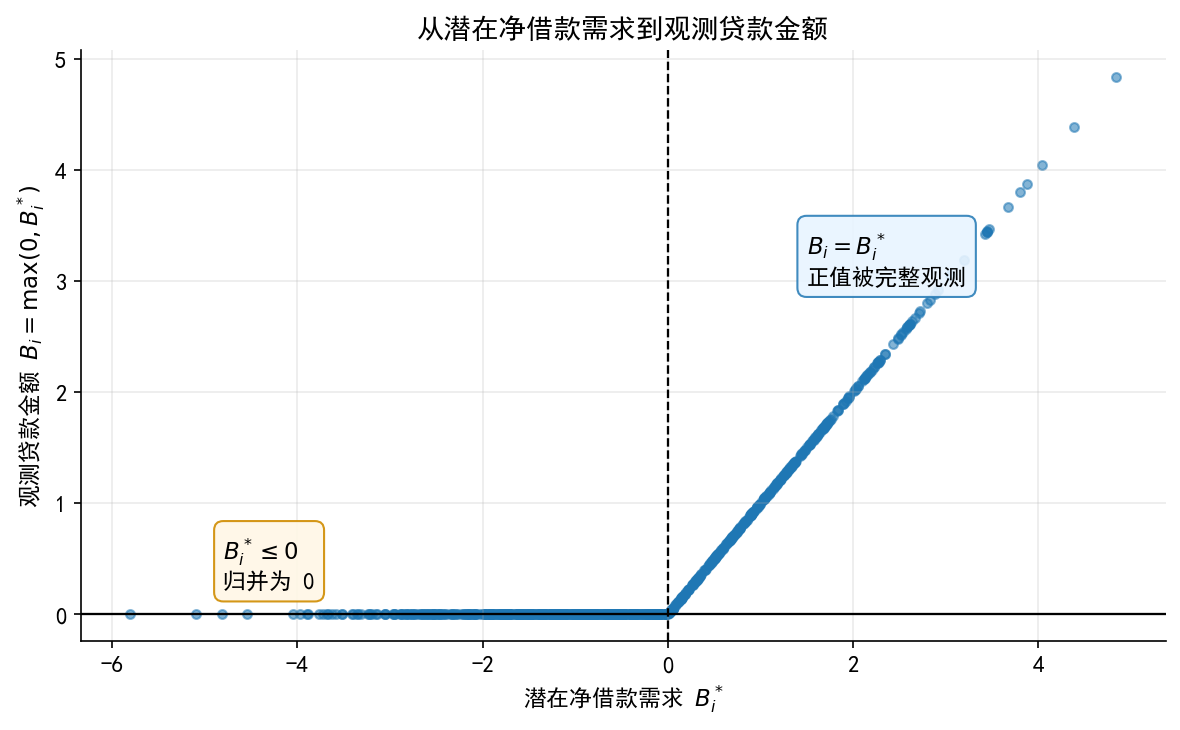

In [60]:
# ------------------------------------------------------------
# 5. 图 1：潜变量到观测变量
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sample = df.sample(800, random_state=20260429).sort_values("loan_latent")
ax.scatter(sample["loan_latent"], sample["loan_amt"], s=18, alpha=0.55)

ax.axvline(0, color="black", linewidth=1.1, linestyle="--")
ax.axhline(0, color="black", linewidth=1.1)

ax.set_xlabel(r"潜在净借款需求 $B_i^*$")
ax.set_ylabel(r"观测贷款金额 $B_i=\max(0,B_i^*)$")
ax.set_title("从潜在净借款需求到观测贷款金额")

ax.text(
    -4.8, 0.20,
    r"$B_i^*\leq 0$" + "\n归并为 0",
    ha="left", va="bottom", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", fc="#fff7e6", ec="#d08c00", alpha=0.9)
)

ax.text(
    1.5, 3.2,
    r"$B_i=B_i^*$" + "\n正值被完整观测",
    ha="left", va="center", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", fc="#e8f4ff", ec="#2c7fb8", alpha=0.9)
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig01_latent_to_observed.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig01_latent_to_observed.svg", bbox_inches="tight")
plt.show()

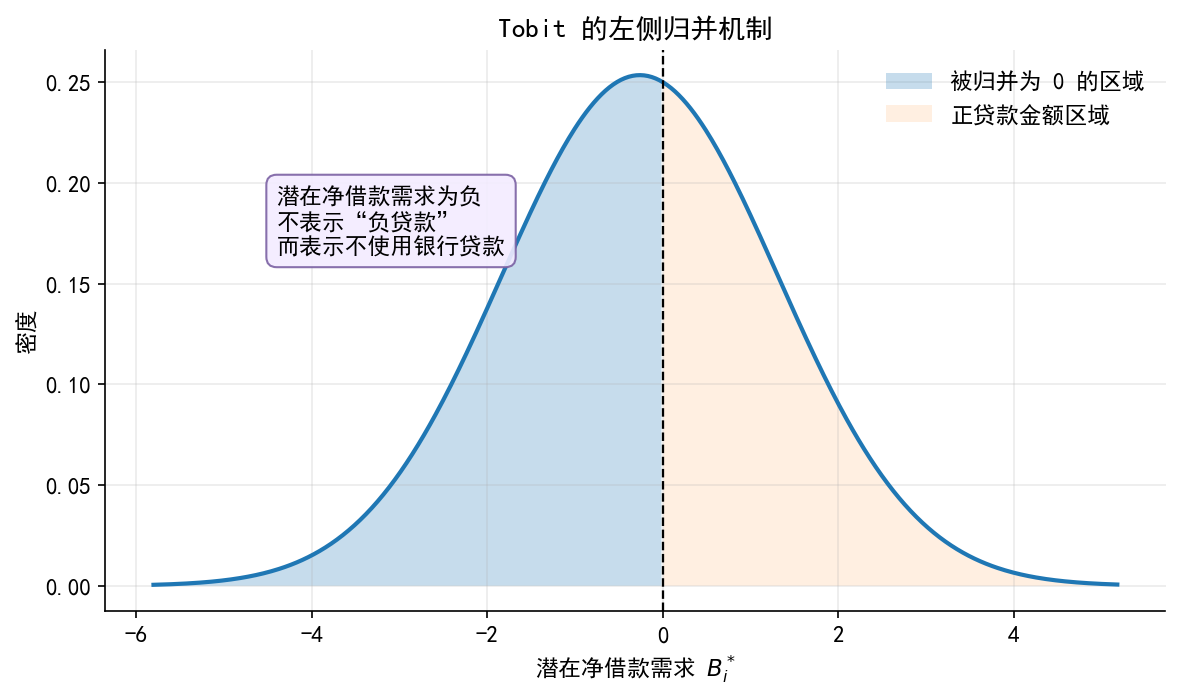

In [61]:
# ------------------------------------------------------------
# 6. 图 2：潜变量分布与归并区域
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8))

xgrid = np.linspace(df["loan_latent"].min(), df["loan_latent"].max(), 500)
m, s = df["loan_latent"].mean(), df["loan_latent"].std()
density = norm.pdf(xgrid, loc=m, scale=s)

ax.plot(xgrid, density, linewidth=2)
ax.fill_between(xgrid[xgrid <= 0], density[xgrid <= 0], alpha=0.25, label="被归并为 0 的区域")
ax.fill_between(xgrid[xgrid > 0], density[xgrid > 0], alpha=0.12, label="正贷款金额区域")
ax.axvline(0, color="black", linewidth=1.1, linestyle="--")

ax.set_xlabel(r"潜在净借款需求 $B_i^*$")
ax.set_ylabel("密度")
ax.set_title("Tobit 的左侧归并机制")
ax.legend(frameon=False, loc="upper right")

ax.text(
    -4.4, density.max() * 0.65,
    "潜在净借款需求为负\n不表示“负贷款”\n而表示不使用银行贷款",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", fc="#f3ecff", ec="#7b61a3", alpha=0.9)
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig02_censoring_mechanism.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig02_censoring_mechanism.svg", bbox_inches="tight")
plt.show()

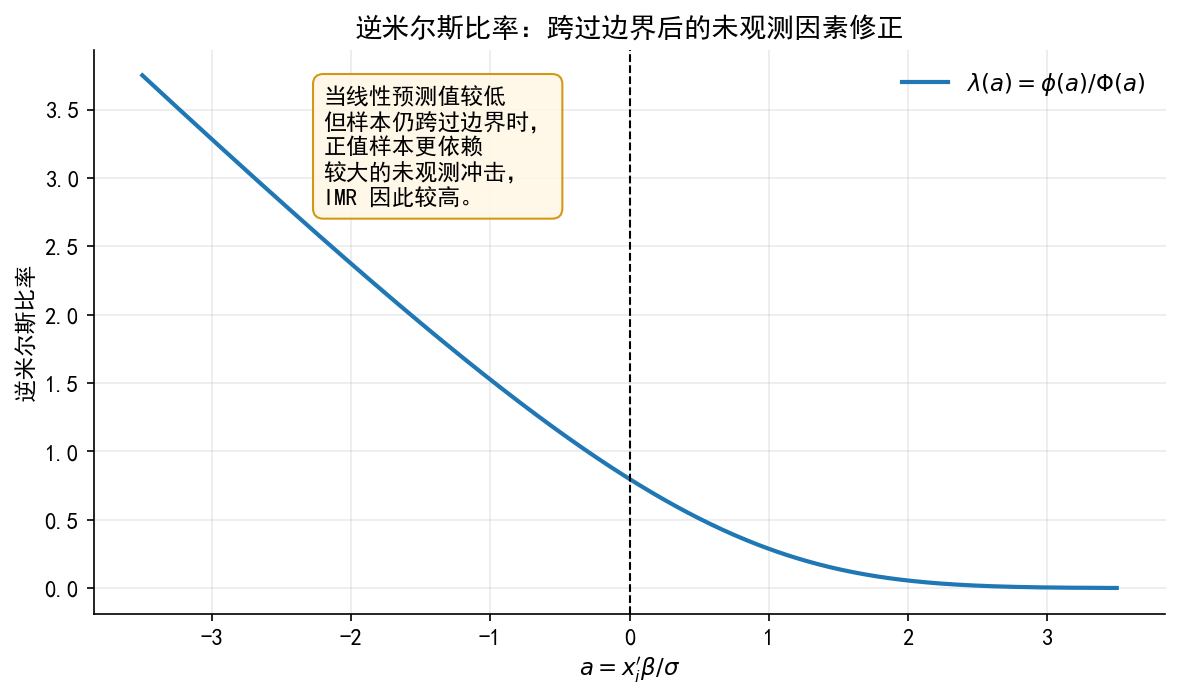

In [62]:
# ------------------------------------------------------------
# 7. 图 3：逆米尔斯比率曲线
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8))

agrid = np.linspace(-3.5, 3.5, 500)
Phi_grid = np.clip(norm.cdf(agrid), 1e-12, 1)
imr_grid = norm.pdf(agrid) / Phi_grid

ax.plot(agrid, imr_grid, linewidth=2, label=r"$\lambda(a)=\phi(a)/\Phi(a)$")
ax.axvline(0, color="black", linewidth=1.0, linestyle="--")

ax.set_xlabel(r"$a=x_i^\prime\beta/\sigma$")
ax.set_ylabel("逆米尔斯比率")
ax.set_title("逆米尔斯比率：跨过边界后的未观测因素修正")
ax.legend(frameon=False)

ax.text(
    -2.2, 2.8,
    "当线性预测值较低\n但样本仍跨过边界时，\n"
    "正值样本更依赖\n较大的未观测冲击，\n"
    "IMR 因此较高。",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", fc="#fff7e6", ec="#d08c00", alpha=0.9)
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig03_imr_curve.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig03_imr_curve.svg", bbox_inches="tight")
plt.show()

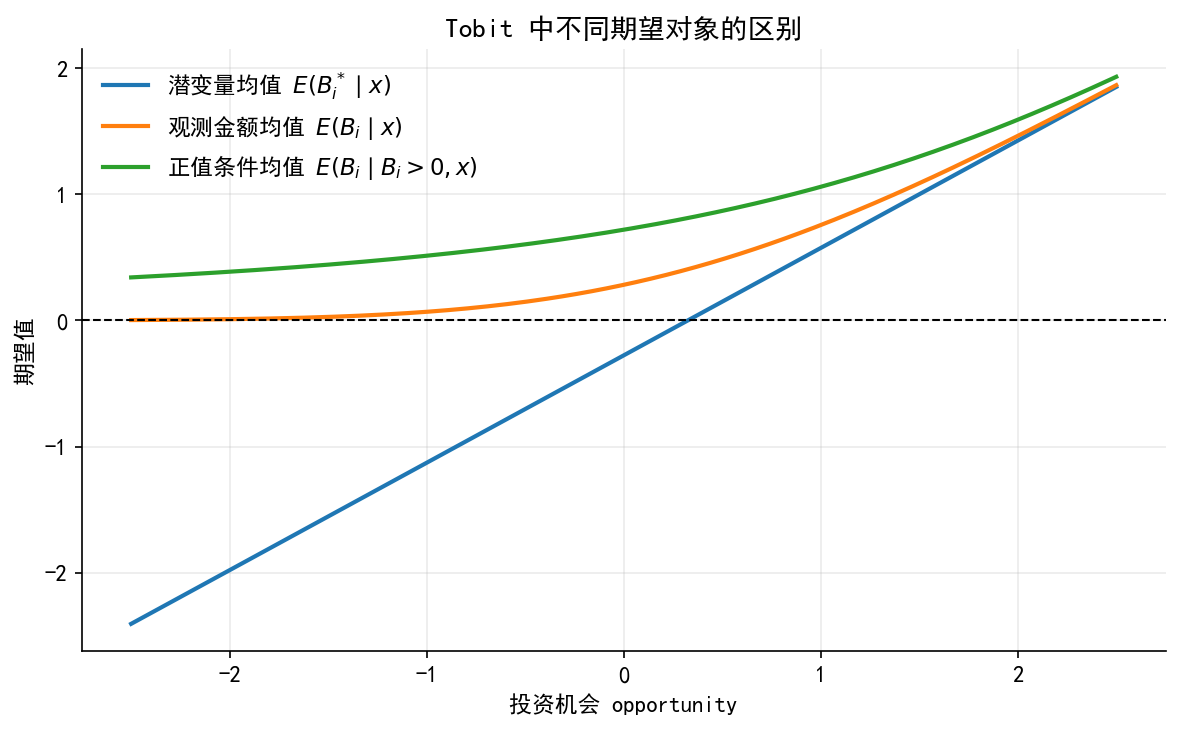

In [63]:
# ------------------------------------------------------------
# 8. 图 4：Tobit 中不同期望对象的区别
# ------------------------------------------------------------

opp_grid = np.linspace(-2.5, 2.5, 200)

# 只改变 opportunity，其余变量固定在标准化均值 0
Xg = pd.DataFrame({
    "const": 1.0,
    "opportunity": opp_grid,
    "collateral": 0.0,
    "cash": 0.0,
})

mu_g, a_g, p_g, Ey_g, Eypos_g, lam_g = tobit_quantities(beta_hat, sigma_hat, Xg.values)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(opp_grid, mu_g, linewidth=2, label=r"潜变量均值 $E(B_i^*\mid x)$")
ax.plot(opp_grid, Ey_g, linewidth=2, label=r"观测金额均值 $E(B_i\mid x)$")
ax.plot(opp_grid, Eypos_g, linewidth=2, label=r"正值条件均值 $E(B_i\mid B_i>0,x)$")
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")

ax.set_xlabel("投资机会 opportunity")
ax.set_ylabel("期望值")
ax.set_title("Tobit 中不同期望对象的区别")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig04_expectations.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig04_expectations.svg", bbox_inches="tight")
plt.show()

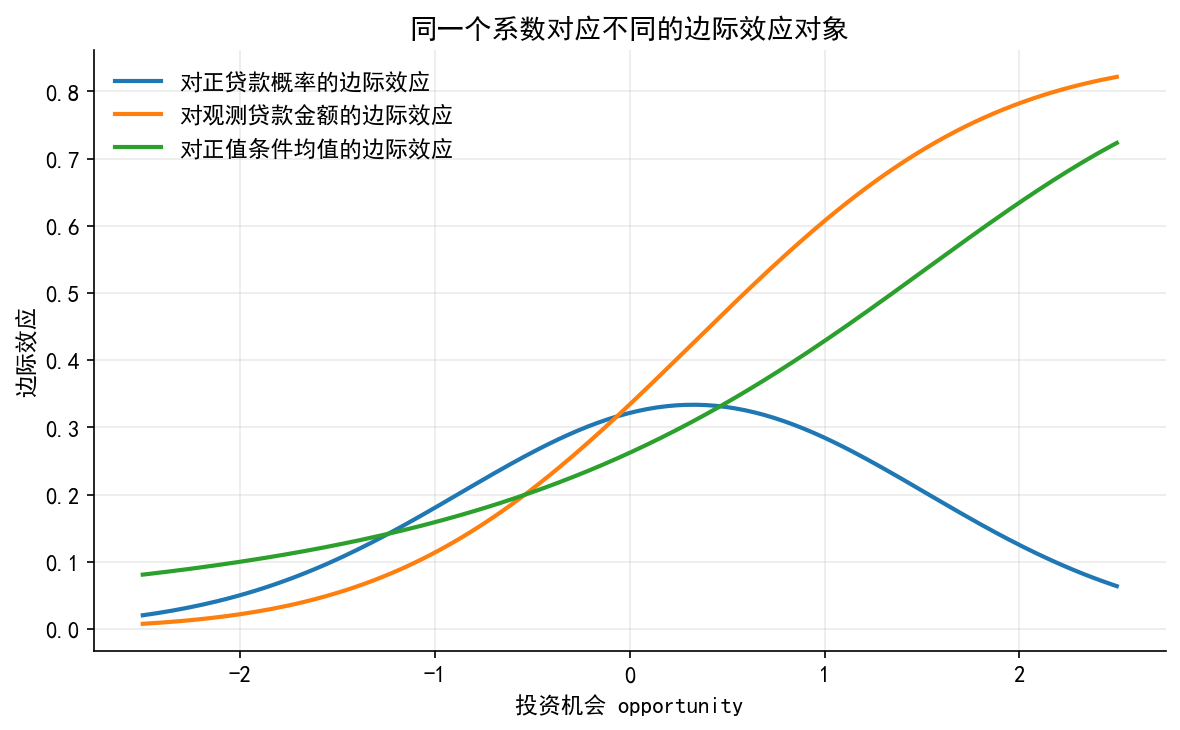

In [64]:
# ------------------------------------------------------------
# 9. 图 5：边际效应随 opportunity 的变化
# ------------------------------------------------------------

me_prob = norm.pdf(a_g) * beta_hat[1] / sigma_hat
me_uncond = p_g * beta_hat[1]
me_cond = beta_hat[1] * (1 - lam_g * (a_g + lam_g))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(opp_grid, me_prob, linewidth=2, label="对正贷款概率的边际效应")
ax.plot(opp_grid, me_uncond, linewidth=2, label="对观测贷款金额的边际效应")
ax.plot(opp_grid, me_cond, linewidth=2, label="对正值条件均值的边际效应")

ax.set_xlabel("投资机会 opportunity")
ax.set_ylabel("边际效应")
ax.set_title("同一个系数对应不同的边际效应对象")
ax.legend(frameon=False, loc="best")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig05_marginal_effects.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig05_marginal_effects.svg", bbox_inches="tight")
plt.show()

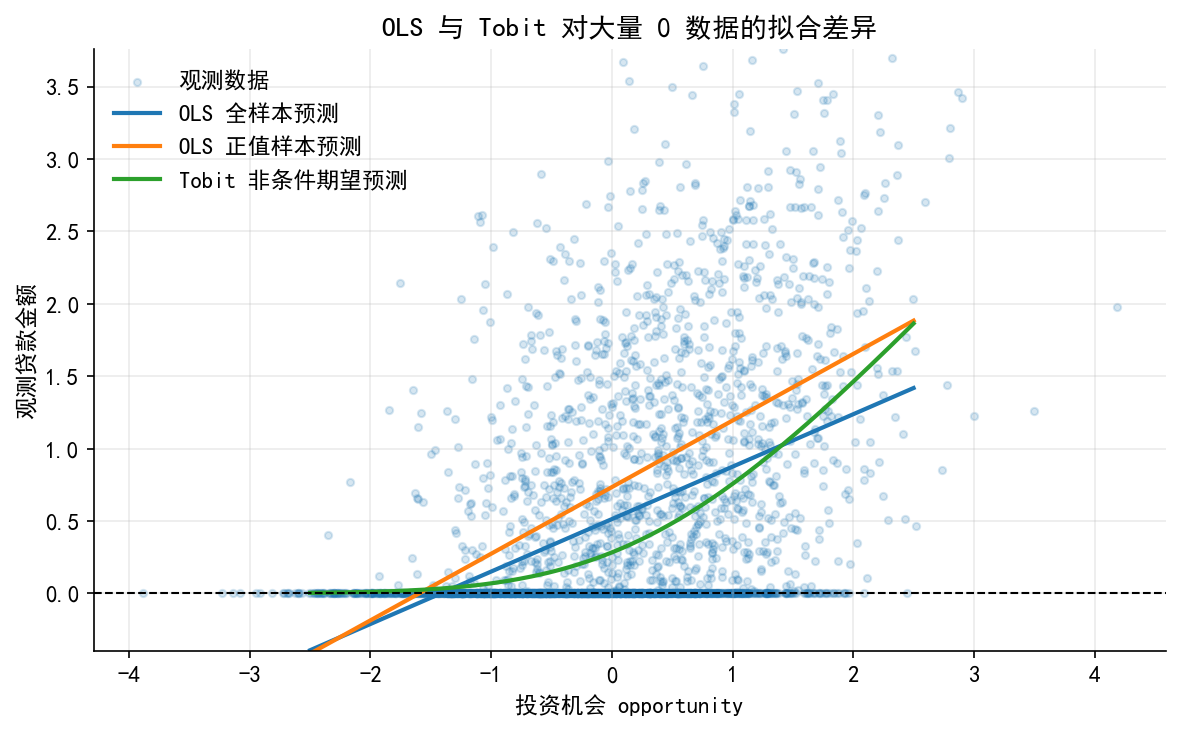

In [65]:
# ------------------------------------------------------------
# 10. 图 6：OLS 与 Tobit 预测比较
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["opportunity"], df["loan_amt"], s=12, alpha=0.18, label="观测数据")

pred_ols_all = ols_all.predict(Xg)
pred_ols_pos = ols_pos.predict(Xg)
pred_tobit = Ey_g

ax.plot(opp_grid, pred_ols_all, linewidth=2, label="OLS 全样本预测")
ax.plot(opp_grid, pred_ols_pos, linewidth=2, label="OLS 正值样本预测")
ax.plot(opp_grid, pred_tobit, linewidth=2, label="Tobit 非条件期望预测")

ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel("投资机会 opportunity")
ax.set_ylabel("观测贷款金额")
ax.set_ylim(-0.4, df["loan_amt"].quantile(0.995))
ax.set_title("OLS 与 Tobit 对大量 0 数据的拟合差异")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig06_ols_vs_tobit.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig06_ols_vs_tobit.svg", bbox_inches="tight")
plt.show()

In [66]:
# ------------------------------------------------------------
# 11. 输出关键结果，便于讲义引用
# ------------------------------------------------------------

summary = {
    "n": len(df),
    "zero_share": float((df["loan_amt"] == 0).mean()),
    "sigma_hat": float(sigma_hat),
    "mean_p_positive": float(np.mean(p_hat)),
    "mean_E_y": float(np.mean(Ey_hat)),
    "mean_E_y_positive": float(np.mean(Ey_pos_hat)),
}

pd.Series(summary).to_csv("./data/tobit_summary.csv", encoding="utf-8-sig")
summary

{'n': 3000,
 'zero_share': 0.5676666666666667,
 'sigma_hat': 1.0172324665351988,
 'mean_p_positive': 0.4326806722557415,
 'mean_E_y': 0.5097678503381394,
 'mean_E_y_positive': 0.8574573742541898}


# 附录：Winkelmann 风格图形的 Python 复现

下面几张图复现并扩展讲义中用于解释截断正态分布、逆米尔斯比率和 Tobit 条件期望的经典图形。  
输出文件名与讲义中引用的外链图片保持一致，便于以后将图床链接替换为本地相对路径。


In [67]:

# ------------------------------------------------------------
# 12. 附录图：Winkelmann 风格图形的 Python 复现
# ------------------------------------------------------------

# 说明：
# - 这些图复现讲义中用于解释截断正态分布、IMR 和 Tobit 条件期望的图形；
# - 文件名与原讲义外链图片一致，便于后续将讲义中的图床链接改为 ./figs/...；
# - 同时输出 PNG 和 SVG，PNG 适合网页和公众号，SVG 适合 HTML 讲义高清显示。

def save_png_svg(fig, basename, dpi=300):
    """同时保存 PNG 与 SVG，统一图片输出规范。"""
    fig.savefig(f"./figs/{basename}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"./figs/{basename}.svg", bbox_inches="tight")


def setup_winkel_axis(ax):
    """统一设置 Winkelmann 风格图形的坐标轴样式。"""
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.7)


def imr_lower_tail(delta):
    """
    计算 lambda(delta)=phi(delta)/Phi(delta)。
    在 Tobit 条件均值 E(y|y>0,x) 中，delta=mu/sigma。
    """
    Phi = np.clip(norm.cdf(delta), 1e-12, 1.0)
    return norm.pdf(delta) / Phi


def trunc_normal_left_pdf(y, c=0.0, mu=0.0, sigma=1.0):
    """
    左侧在 c 处截断的正态密度 f(y | y>c)。
    """
    alpha = (c - mu) / sigma
    denom = 1 - norm.cdf(alpha)
    pdf = norm.pdf((y - mu) / sigma) / sigma / denom
    return np.where(y >= c, pdf, np.nan)


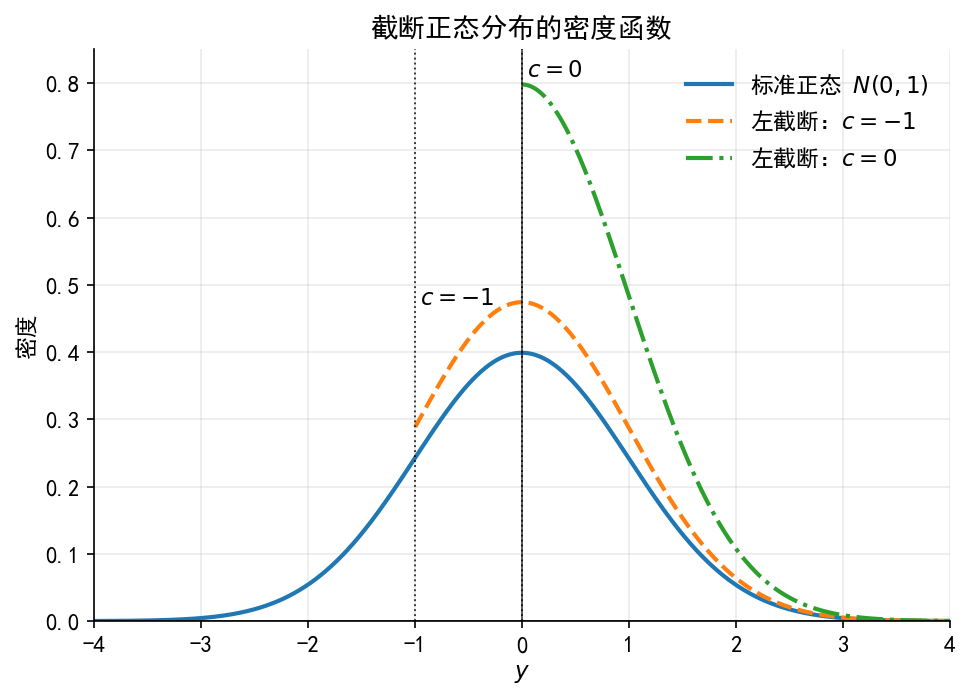

In [68]:

# ------------------------------------------------------------
# 13. 图 A1：截断正态分布的密度函数
# ------------------------------------------------------------

x_grid = np.linspace(-4, 4, 800)

fig, ax = plt.subplots(figsize=(6.6, 4.8))

ax.plot(
    x_grid,
    norm.pdf(x_grid),
    linewidth=2.0,
    linestyle="-",
    label=r"标准正态 $N(0,1)$"
)

ax.plot(
    x_grid,
    trunc_normal_left_pdf(x_grid, c=-1),
    linewidth=2.0,
    linestyle="--",
    label=r"左截断：$c=-1$"
)

ax.plot(
    x_grid,
    trunc_normal_left_pdf(x_grid, c=0),
    linewidth=2.0,
    linestyle="-.",
    label=r"左截断：$c=0$"
)

# 标出截断点，帮助读者理解：截断不是归并，而是截断点以下的样本不进入分布。
for c, ypos in [(-1, 0.47), (0, 0.81)]:
    ax.axvline(c, color="black", linewidth=0.9, linestyle=":", alpha=0.8)
    ax.text(c + 0.05, ypos, rf"$c={c}$", fontsize=11)

setup_winkel_axis(ax)

ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.85)
ax.set_xlabel(r"$y$")
ax.set_ylabel("密度")
ax.set_title("截断正态分布的密度函数")
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
save_png_svg(fig, "limit_dep_tobit_fig07_truncnormal_density")
plt.show()


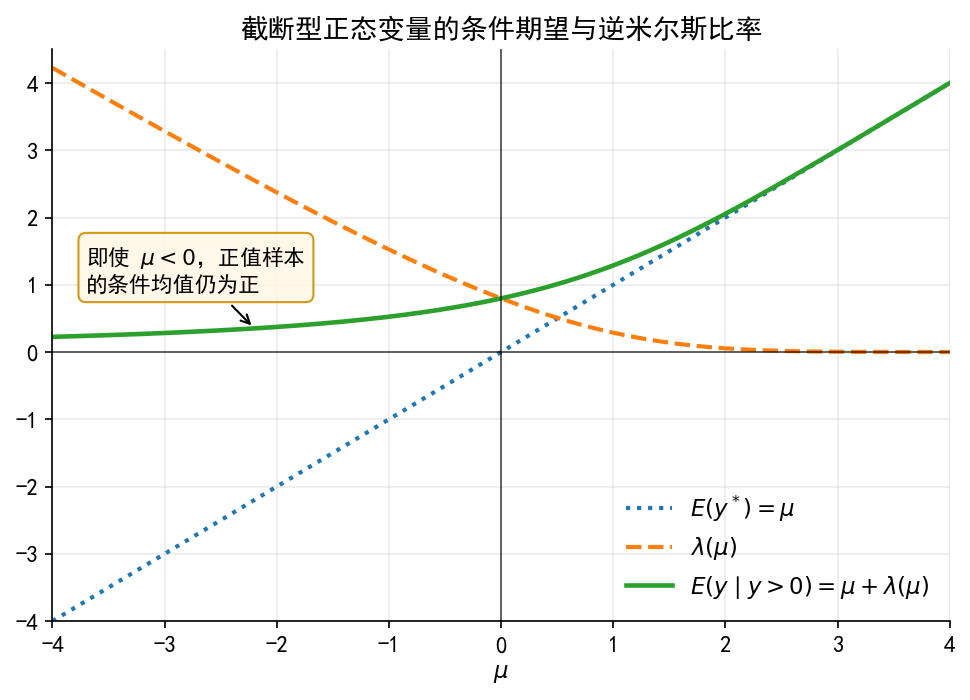

In [69]:

# ------------------------------------------------------------
# 14. 图 A2：截断正态分布的条件期望与 IMR
# ------------------------------------------------------------

mu_grid = np.linspace(-4, 4, 800)
sigma = 1.0

# 当 c=0 且 sigma=1 时：
# E(y*|x)=mu
# lambda(mu)=phi(mu)/Phi(mu)
# E(y | y>0, x)=mu+lambda(mu)
lam = imr_lower_tail(mu_grid / sigma)
Ey_pos = mu_grid + sigma * lam

fig, ax = plt.subplots(figsize=(6.6, 4.8))

ax.plot(
    mu_grid,
    mu_grid,
    linewidth=2.0,
    linestyle=":",
    label=r"$E(y^*)=\mu$"
)

ax.plot(
    mu_grid,
    lam,
    linewidth=2.0,
    linestyle="--",
    label=r"$\lambda(\mu)$"
)

ax.plot(
    mu_grid,
    Ey_pos,
    linewidth=2.2,
    linestyle="-",
    label=r"$E(y\mid y>0)=\mu+\lambda(\mu)$"
)

setup_winkel_axis(ax)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4.5)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("")
ax.set_title("截断型正态变量的条件期望与逆米尔斯比率")
ax.legend(frameon=False, loc="lower right")

# 关键直觉标注：mu 很低时，条件均值不会跟着 mu 变成负数。
ax.annotate(
    "即使 $\\mu<0$，正值样本\n的条件均值仍为正",
    xy=(-2.2, Ey_pos[np.argmin(np.abs(mu_grid + 2.2))]),
    xytext=(-3.7, 0.9),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="#fff7e6", ec="#d08c00", alpha=0.90)
)

fig.tight_layout()
save_png_svg(fig, "limit_dep_tobit_fig08_truncnormal_imr")
plt.show()


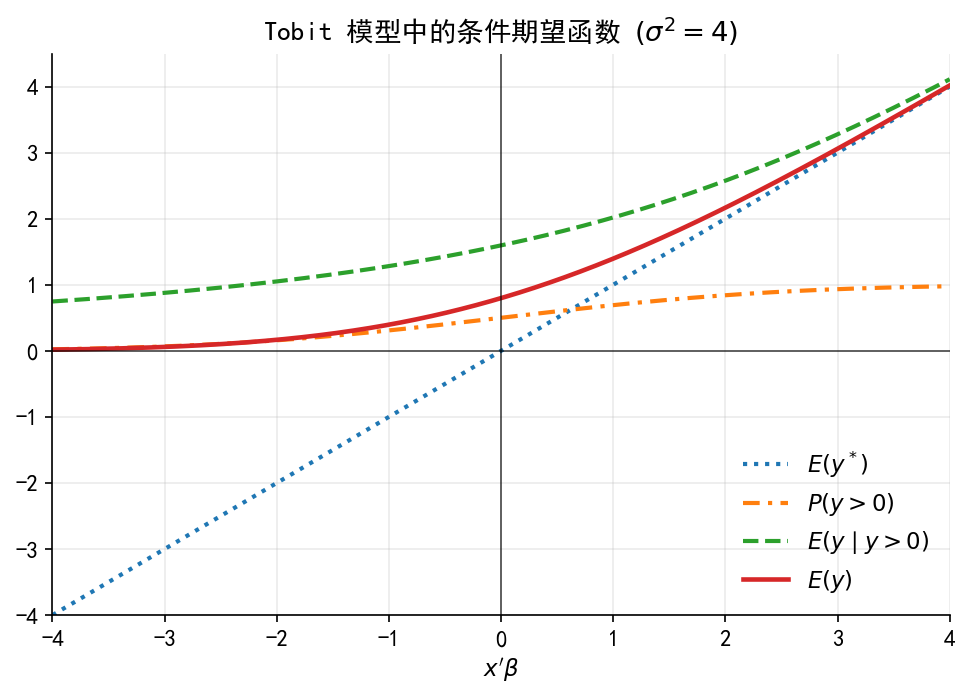

In [70]:

# ------------------------------------------------------------
# 15. 图 A3：Tobit 模型中的条件期望函数
# ------------------------------------------------------------

xb_grid = np.linspace(-4, 4, 800)
sigma = 2.0

a = xb_grid / sigma
Phi = norm.cdf(a)
lam = imr_lower_tail(a)

Ey_star = xb_grid
P_pos = Phi
Ey_pos = xb_grid + sigma * lam
Ey = Phi * Ey_pos

fig, ax = plt.subplots(figsize=(6.6, 4.8))

ax.plot(
    xb_grid,
    Ey_star,
    linewidth=2.0,
    linestyle=":",
    label=r"$E(y^*)$"
)

ax.plot(
    xb_grid,
    P_pos,
    linewidth=2.0,
    linestyle=(0, (4, 2, 1, 2)),
    label=r"$P(y>0)$"
)

ax.plot(
    xb_grid,
    Ey_pos,
    linewidth=2.0,
    linestyle="--",
    label=r"$E(y\mid y>0)$"
)

ax.plot(
    xb_grid,
    Ey,
    linewidth=2.2,
    linestyle="-",
    label=r"$E(y)$"
)

setup_winkel_axis(ax)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4.5)
ax.set_xlabel(r"$x'\beta$")
ax.set_ylabel("")
ax.set_title(r"Tobit 模型中的条件期望函数 $(\sigma^2=4)$")
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
save_png_svg(fig, "limit_dep_tobit_fig09_truncnormal_expectation")
plt.show()


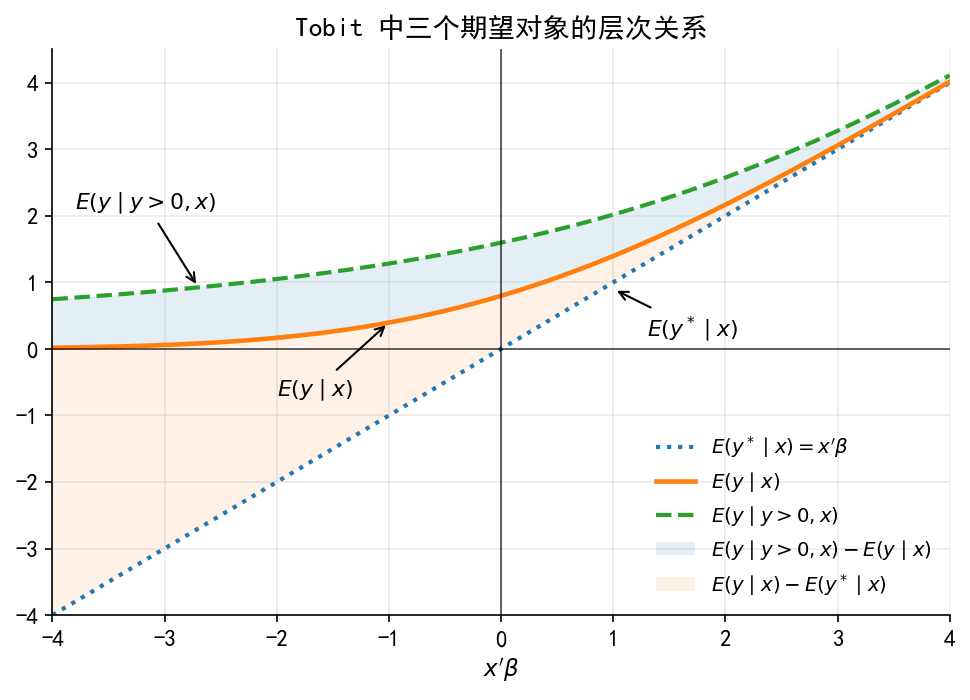

In [71]:

# ------------------------------------------------------------
# 16. 图 A4：Tobit 条件期望的层次关系
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.6, 4.8))

ax.plot(
    xb_grid,
    Ey_star,
    linewidth=2.0,
    linestyle=":",
    label=r"$E(y^*\mid x)=x'\beta$"
)

ax.plot(
    xb_grid,
    Ey,
    linewidth=2.2,
    linestyle="-",
    label=r"$E(y\mid x)$"
)

ax.plot(
    xb_grid,
    Ey_pos,
    linewidth=2.0,
    linestyle="--",
    label=r"$E(y\mid y>0,x)$"
)

# 用淡色区域强调三类期望的层次差异。
ax.fill_between(
    xb_grid,
    Ey,
    Ey_pos,
    alpha=0.12,
    label=r"$E(y\mid y>0,x)-E(y\mid x)$"
)

ax.fill_between(
    xb_grid,
    Ey_star,
    Ey,
    where=Ey >= Ey_star,
    alpha=0.10,
    label=r"$E(y\mid x)-E(y^*\mid x)$"
)

setup_winkel_axis(ax)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4.5)
ax.set_xlabel(r"$x'\beta$")
ax.set_ylabel("")
ax.set_title("Tobit 中三个期望对象的层次关系")

ax.annotate(
    r"$E(y\mid y>0,x)$",
    xy=(-2.7, Ey_pos[np.argmin(np.abs(xb_grid + 2.7))]),
    xytext=(-3.8, 2.1),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10.5
)

ax.annotate(
    r"$E(y\mid x)$",
    xy=(-1.0, Ey[np.argmin(np.abs(xb_grid + 1.0))]),
    xytext=(-2.0, -0.7),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10.5
)

ax.annotate(
    r"$E(y^*\mid x)$",
    xy=(1.0, 0.9),
    xytext=(1.3, 0.2),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10.5
)

ax.legend(frameon=False, loc="lower right", fontsize=9.5)

fig.tight_layout()
save_png_svg(fig, "limit_dep_tobit_fig09_truncnormal_expectationA")
plt.show()


# 附录：旧版概念图的保留与更新

下面几张图保留自旧版 `04_codes.ipynb` 的设计。它们的作用是先用最简单的图形说明 Tobit 的基本观测机制：潜变量可以连续变化，但观测变量在 0 点出现堆积。

这些图与企业信贷主案例并不冲突。主案例用贷款金额解释 $B_i^*$ 的经济含义；这里的图则用于帮助初学者从图形上理解“潜变量—观测变量—0 点堆积”的关系。

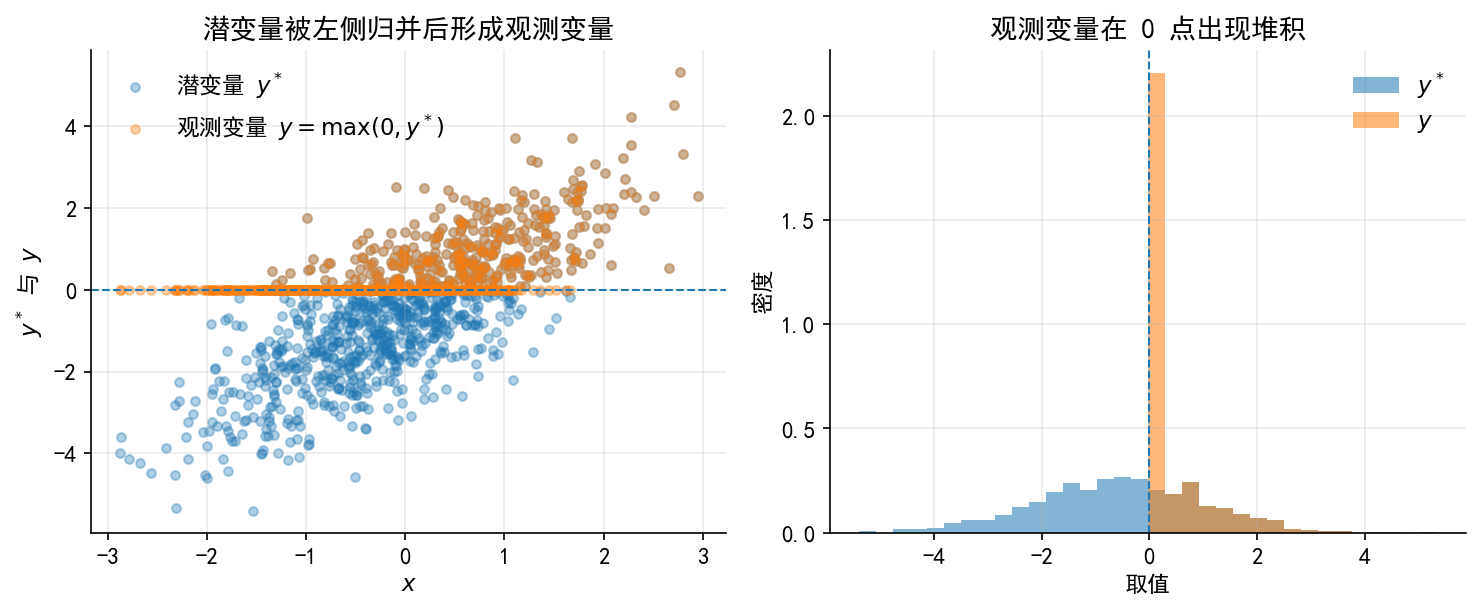

In [72]:
# ------------------------------------------------------------
# 17. 保留旧版图 1：潜变量 y* 与观测变量 y 的关系
# ------------------------------------------------------------

rng_old = np.random.default_rng(20260428)

n = 1000
x = rng_old.normal(0, 1, n)
u = rng_old.normal(0, 1, n)

# 潜变量：可理解为潜在净收益、潜在需求强度或潜在净借款需求
y_latent = -0.5 + 1.2 * x + u

# 观测变量：当潜变量小于等于 0 时，只能观察到 y=0
y_obs = np.maximum(0, y_latent)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# 左图：潜变量与观测变量
axes[0].scatter(x, y_latent, alpha=0.35, s=18, label=r"潜变量 $y^*$")
axes[0].scatter(x, y_obs, alpha=0.35, s=18, label=r"观测变量 $y=\max(0,y^*)$")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y^*$ 与 $y$")
axes[0].set_title("潜变量被左侧归并后形成观测变量")
axes[0].legend(frameon=False)

# 右图：分布对比
bins = np.linspace(min(y_latent.min(), y_obs.min()), max(y_latent.max(), y_obs.max()), 35)
axes[1].hist(y_latent, bins=bins, alpha=0.55, density=True, label=r"$y^*$")
axes[1].hist(y_obs, bins=bins, alpha=0.55, density=True, label=r"$y$")
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("取值")
axes[1].set_ylabel("密度")
axes[1].set_title("观测变量在 0 点出现堆积")
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig01_latent_observed.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig01_latent_observed.svg", bbox_inches="tight")
plt.show()

样本量: 2500
rd=0 的比例: 59.44%


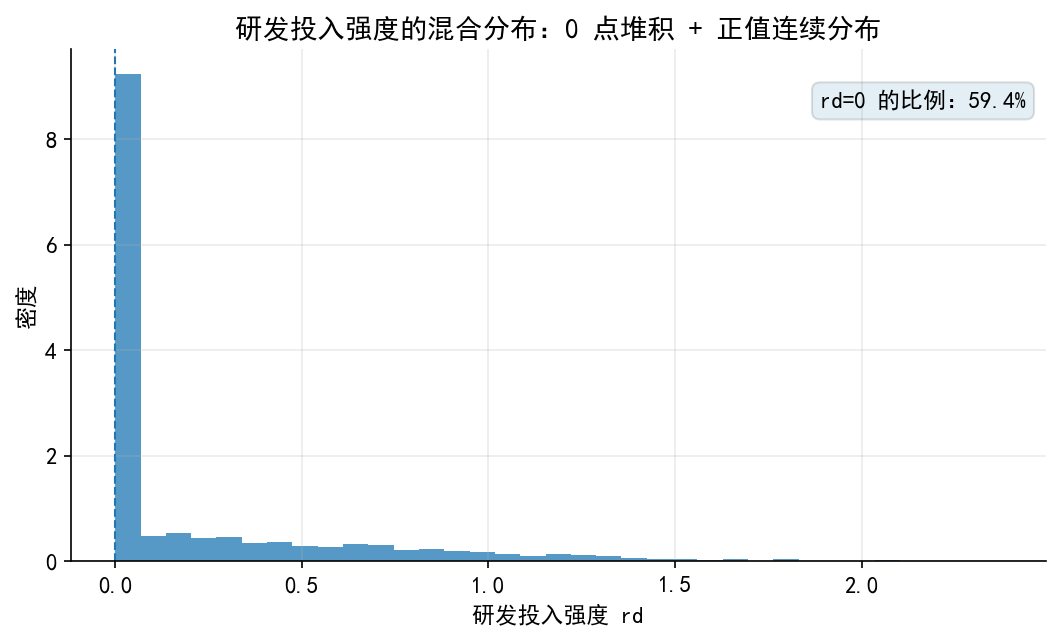

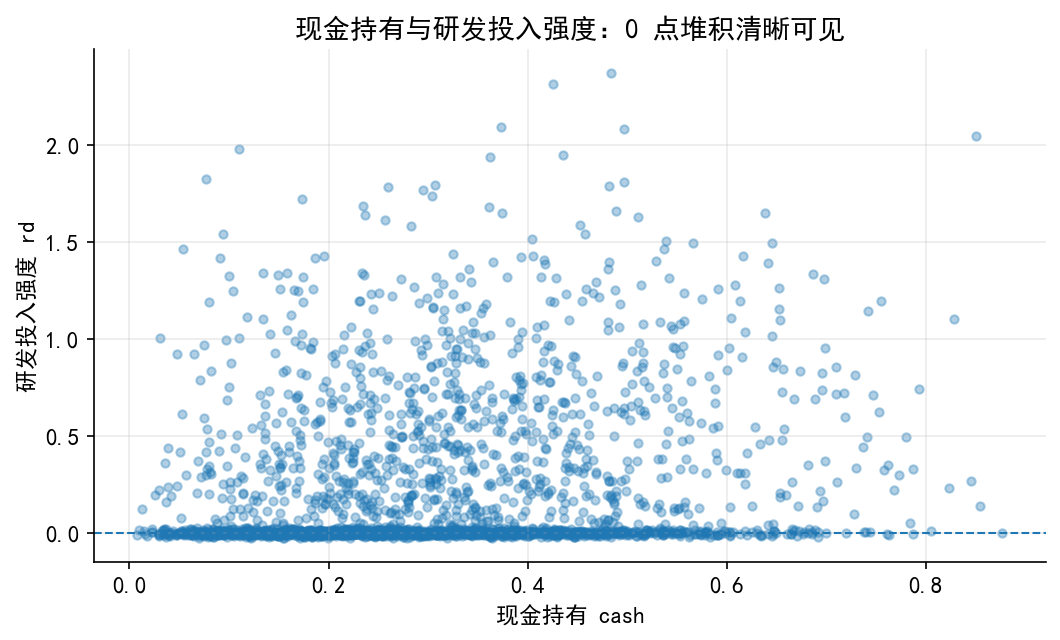

In [73]:
# ------------------------------------------------------------
# 18. 保留旧版图 2-3：研发投入强度中的 0 点堆积
# ------------------------------------------------------------

n = 2500

# 企业规模：可理解为标准化后的 log(总资产)
size = rng_old.normal(0, 1, n)

# 现金持有：为了简化，生成一个 0 到 1 之间的变量
cash = rng_old.beta(2.2, 5.0, n)

# 资产负债率：0 到 1 之间
lev = rng_old.beta(2.3, 3.0, n)

# 成长性和盈利能力：允许出现少量负值
growth = rng_old.normal(0.08, 0.22, n)
profit = rng_old.normal(0.05, 0.08, n)

# 随机扰动
sigma_true_rd = 0.65
u = rng_old.normal(0, sigma_true_rd, n)

# 潜在研发投入净收益或潜在研发投入强度
# 经济含义：
# - size 越大，研发项目吸收能力越强；
# - cash 越高，内部融资约束越弱；
# - lev 越高，债务约束越强；
# - growth 和 profit 越高，研发投入动机越强。
rd_latent = (
    -0.45
    + 0.35 * size
    + 1.20 * cash
    - 0.55 * lev
    + 0.75 * growth
    + 1.10 * profit
    + u
)

# 观测到的研发投入强度：左侧归并于 0
rd = np.maximum(0, rd_latent)

df_rd = pd.DataFrame({
    "rd": rd,
    "rd_latent": rd_latent,
    "size": size,
    "cash": cash,
    "lev": lev,
    "growth": growth,
    "profit": profit
})

df_rd.to_csv("./data/tobit_rd_sim.csv", index=False, encoding="utf-8-sig")

zero_share_rd = (df_rd["rd"] == 0).mean()
print(f"样本量: {len(df_rd)}")
print(f"rd=0 的比例: {zero_share_rd:.2%}")

# 图 2：研发投入强度的分布
fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.hist(df_rd["rd"], bins=35, alpha=0.75, density=True)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("研发投入强度 rd")
ax.set_ylabel("密度")
ax.set_title("研发投入强度的混合分布：0 点堆积 + 正值连续分布")

txt = f"rd=0 的比例：{zero_share_rd:.1%}"
ax.text(
    0.98, 0.92, txt, transform=ax.transAxes, ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.12)
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig02_rd_distribution.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig02_rd_distribution.svg", bbox_inches="tight")
plt.show()

# 图 3：归并点附近的数据特征
fig, ax = plt.subplots(figsize=(7.2, 4.4))

# 对 rd=0 的点做轻微纵向扰动，避免完全重叠
jitter = rng_old.normal(0, 0.01, len(df_rd))
rd_jitter = df_rd["rd"] + np.where(df_rd["rd"] == 0, jitter, 0)

ax.scatter(df_rd["cash"], rd_jitter, s=16, alpha=0.35)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("现金持有 cash")
ax.set_ylabel("研发投入强度 rd")
ax.set_title("现金持有与研发投入强度：0 点堆积清晰可见")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig03_censoring_pattern.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/limit_dep_tobit_fig03_censoring_pattern.svg", bbox_inches="tight")
plt.show()